<a href="https://colab.research.google.com/github/tarunsac/Gen-AI/blob/main/applied_ml_assignment_nyc_taxi_trip_duration_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the `nyc_taxi_trip_duration.csv` dataset, perform data cleaning and feature engineering, train a regression model to predict trip duration, evaluate its performance, and visualize the predictions.

## Load Dataset

### Subtask:
Load the `nyc_taxi_trip_duration.csv` dataset into a pandas DataFrame.


**Reasoning**:
To load the dataset, the pandas library must first be imported. Then, the `pd.read_csv()` function will be used to load the specified CSV file into a DataFrame, and `.head()` will display the initial rows for verification.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/nyc_taxi_trip_duration.csv')
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400.0
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100.0
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635.0
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141.0
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848.0


## Initial Data Inspection and Cleaning

### Subtask:
Inspect the dataset for its structure, data types, and check for any missing values. Address any initial data cleaning needs.


**Reasoning**:
The first step is to inspect the dataset's structure, data types, and missing values, and then convert the datetime columns to the correct format as specified in the instructions. This will provide a comprehensive overview of the dataset's current state and prepare the datetime columns for further analysis.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

print("\nData types after conversion:")
df[['pickup_datetime', 'dropoff_datetime']].info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB

Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0

## Feature Engineering

### Subtask:
Extract relevant features from existing columns, such as 'pickup_datetime' (e.g., hour, day of the week, month, year) and calculate trip distance from latitude and longitude coordinates.


**Reasoning**:
The subtask requires extracting time-based features, calculating the Haversine distance, and encoding a categorical column. I will use a single code block to perform all these operations by first importing `numpy` for mathematical calculations, then extracting the datetime components, defining and applying the Haversine formula, and finally encoding the 'store_and_fwd_flag' column.



In [ ]:
import numpy as np

# 1. Extract time-based features from 'pickup_datetime'
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year

# 2. Define Haversine distance function
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance

# 3. Apply the Haversine distance function to create a new 'distance' column
df['distance'] = df.apply(lambda row: haversine_distance(row['pickup_latitude'], row['pickup_longitude'],
                                                        row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# 4. Convert 'store_and_fwd_flag' to numerical format
df['store_and_fwd_flag_encoded'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

print("New features added successfully. Displaying first 5 rows with new features:")
print(df[['pickup_hour', 'pickup_day_of_week', 'pickup_month', 'pickup_year', 'distance', 'store_and_fwd_flag_encoded']].head())

New features added successfully. Displaying first 5 rows with new features:
   pickup_hour  pickup_day_of_week  pickup_month  pickup_year  distance  \
0           16                   0             2         2016  1.199073   
1           23                   4             3         2016  4.129111   
2           17                   6             2         2016  7.250753   
3            9                   1             1         2016  2.361097   
4            6                   2             2         2016  4.328534   

   store_and_fwd_flag_encoded  
0                           0  
1                           0  
2                           0  
3                           0  
4                           0  


## Data Preprocessing and Splitting

### Subtask:
Prepare the data for model training by selecting relevant features and splitting the dataset into training and testing sets.


**Reasoning**:
To prepare the data for model training, I will first define the feature matrix `X` and the target vector `y` by selecting the specified columns. Then, I will import `train_test_split` from `sklearn.model_selection` and use it to split the data into training and testing sets, as per the instructions.



In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define the feature matrix X
X = df[['vendor_id', 'passenger_count', 'pickup_hour', 'pickup_day_of_week',
        'pickup_month', 'pickup_year', 'distance', 'store_and_fwd_flag_encoded']]

# 2. Define the target vector y
y = df['trip_duration']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data successfully split into training and testing sets.
X_train shape: (583457, 8)
X_test shape: (145865, 8)
y_train shape: (583457,)
y_test shape: (145865,)


## Train Regression Model

### Subtask:
Train a suitable regression model (e.g., a RandomForestRegressor or GradientBoostingRegressor) using the training data to predict `trip_duration`.


**Reasoning**:
To train a regression model as instructed, I need to import `RandomForestRegressor` from `sklearn.ensemble`, then instantiate it with the specified parameters (`n_estimators=100`, `random_state=42`), and finally train it using the `fit()` method with `X_train` and `y_train`.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate Model Performance

### Subtask:
Make predictions on the test set and calculate the R-squared score to assess the model's performance and accuracy.


**Reasoning**:
To evaluate the model's performance, I will make predictions on the test set, import `r2_score` from `sklearn.metrics`, calculate the R-squared score, and then print the result.



In [ ]:
from sklearn.metrics import r2_score

# 1. Make predictions on the test set
y_pred = model.predict(X_test)

# 2. Calculate the R-squared score
r2 = r2_score(y_test, y_pred)

# 3. Print the R-squared score
print(f"R-squared score: {r2:.4f}")

R-squared score: -0.0188


## Data Preprocessing and Splitting (After Outlier Handling)

### Subtask:
Prepare the data for model training with the cleaned `trip_duration` by selecting relevant features and splitting the dataset into training and testing sets.

**Reasoning**:
Since we've modified the `trip_duration` column, we need to redefine the target vector `y` using the new `trip_duration_cleaned` column. Then, we will split the data into training and testing sets again to ensure the model is trained and evaluated on the cleaned target variable.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define the feature matrix X (using existing features)
X = df[['vendor_id', 'passenger_count', 'pickup_hour', 'pickup_day_of_week',
        'pickup_month', 'pickup_year', 'distance', 'store_and_fwd_flag_encoded']]

# 2. Define the target vector y using the cleaned trip_duration
y = df['trip_duration_cleaned']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split into training and testing sets with cleaned trip duration.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data successfully split into training and testing sets with cleaned trip duration.
X_train shape: (580040, 8)
X_test shape: (145011, 8)
y_train shape: (580040,)
y_test shape: (145011,)


## Train Regression Model (with cleaned data)

### Subtask:
Train the RandomForestRegressor model again using the training data with the cleaned `trip_duration`.

**Reasoning**:
With the updated training data (`y_train` now reflects `trip_duration_cleaned`), I will retrain the RandomForestRegressor model using the same parameters as before. This will allow us to assess the impact of outlier handling on model performance.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate the RandomForestRegressor model
model_cleaned = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model with cleaned data
model_cleaned.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully with cleaned data.")

RandomForestRegressor model trained successfully with cleaned data.


## Evaluate Model Performance (with cleaned data)

### Subtask:
Make predictions on the test set using the model trained on cleaned data and calculate the R-squared score.

**Reasoning**:
To evaluate the retrained model, I will make predictions on the `X_test` set and calculate the R-squared score against the `y_test` (which now contains the cleaned trip durations). This will provide a direct comparison of performance after outlier handling.

In [ ]:
from sklearn.metrics import r2_score

# 1. Make predictions on the test set using the model trained on cleaned data
y_pred_cleaned = model_cleaned.predict(X_test)

# 2. Calculate the R-squared score
r2_cleaned = r2_score(y_test, y_pred_cleaned)

# 3. Print the R-squared score
print(f"R-squared score after outlier handling: {r2_cleaned:.4f}")

R-squared score after outlier handling: 0.6732


## Visualize Predictions (with cleaned data)

### Subtask:
Generate a scatter plot to visualize the actual versus predicted trip durations from the model after outlier handling.

**Reasoning**:
To visually assess the performance of the model after outlier handling, I will generate a scatter plot comparing the actual `y_test` values (cleaned trip durations) with the new `y_pred_cleaned` values. This visualization will help us understand if the predictions are now more aligned with the actual durations.

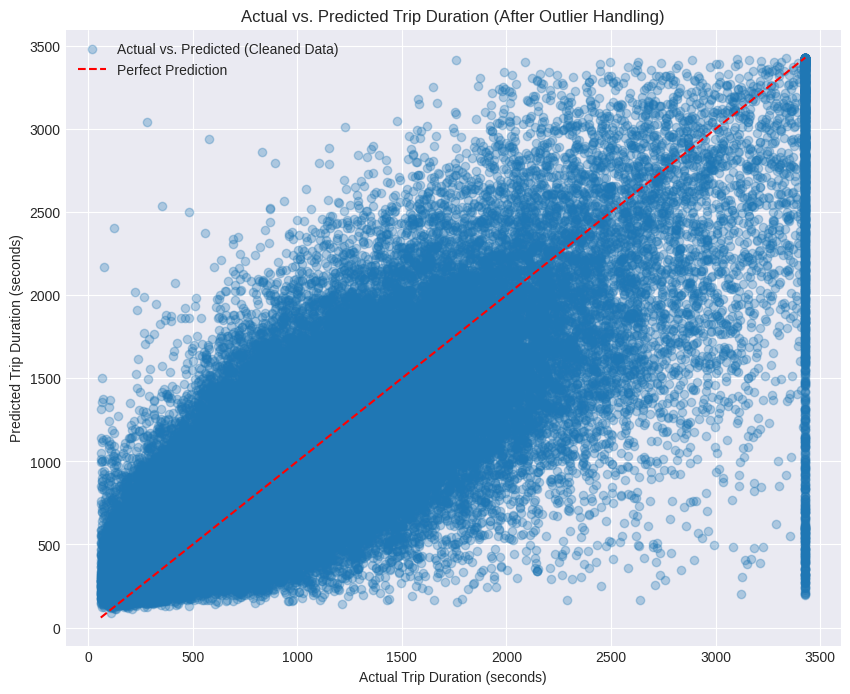

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_cleaned, alpha=0.3, label='Actual vs. Predicted (Cleaned Data)')

# Add a line representing perfect prediction
min_val_cleaned = min(y_test.min(), y_pred_cleaned.min())
max_val_cleaned = max(y_test.max(), y_pred_cleaned.max())

perfect_prediction_line_cleaned = np.linspace(min_val_cleaned, max_val_cleaned, 100)
plt.plot(perfect_prediction_line_cleaned, perfect_prediction_line_cleaned, color='red', linestyle='--', label='Perfect Prediction')

# Label the axes and add a title
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.title('Actual vs. Predicted Trip Duration (After Outlier Handling)')

# Add a legend
plt.legend()

# Display the plot
plt.show()

## Strategies for Improving R-squared Score:

1.  **Outlier Handling**: The `trip_duration` column has a very wide range, from 1 second to over 1.9 million seconds. These extreme values can significantly skew the model's learning and evaluation. Identifying and handling outliers (e.g., removing them, capping them, or transforming the target variable) is a crucial first step.

2.  **Advanced Feature Engineering**: We've extracted basic time-based features and Haversine distance. Further feature engineering could involve:
    *   **Time-of-day categories**: Grouping `pickup_hour` into 'morning_rush', 'daytime', 'evening_rush', 'night'.
    *   **Day-type categories**: Differentiating between weekdays and weekends.
    *   **Weather data**: If available, incorporating weather conditions could be very impactful.
    *   **Traffic data**: Historical traffic patterns could be highly predictive.
    *   **Geographical features**: More sophisticated features based on pickup/dropoff locations, such as distance to major landmarks, density of pickups/dropoffs in an area, or using clustering algorithms (e.g., K-means) to group locations.
    *   **Speed calculation**: `distance / trip_duration` could reveal unusual trips.

3.  **Hyperparameter Tuning**: The current `RandomForestRegressor` was trained with default hyperparameters. Optimizing these parameters (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`) using techniques like GridSearchCV or RandomizedSearchCV can significantly improve model performance.

4.  **Alternative Regression Models**: While Random Forest is a strong model, others might be better suited for this dataset or could offer different performance characteristics. Consider exploring:
    *   **Gradient Boosting Regressors**: Such as XGBoost, LightGBM, or CatBoost, which are known for their strong predictive power.
    *   **Linear Models**: If the relationships are simpler, a linear model might provide a good baseline after proper feature scaling and transformation.

5.  **Target Variable Transformation**: If the `trip_duration` is highly skewed, applying a log transformation (e.g., `np.log1p(trip_duration)`) can help the model learn more effectively, as many regression models assume normally distributed errors.

Let's start by addressing **outliers in `trip_duration`**.

## Outlier Handling for `trip_duration`

### Subtask:
Identify and handle outliers in the `trip_duration` column. We will visualize the distribution of `trip_duration` and then apply a reasonable capping strategy to manage extreme values.

**Reasoning**:
To understand the distribution of `trip_duration` and identify potential outliers, I will first plot a histogram. Then, based on domain knowledge and visual inspection, I will cap the `trip_duration` at a reasonable upper limit (e.g., 99th percentile or a fixed duration like 7200 seconds which is 2 hours, as excessively long trips might be data errors or highly unusual circumstances not representative of typical taxi rides). I will also remove any trips with 0 or extremely low duration, as these are likely erroneous. After capping, I will replot the histogram and check descriptive statistics to confirm the change.

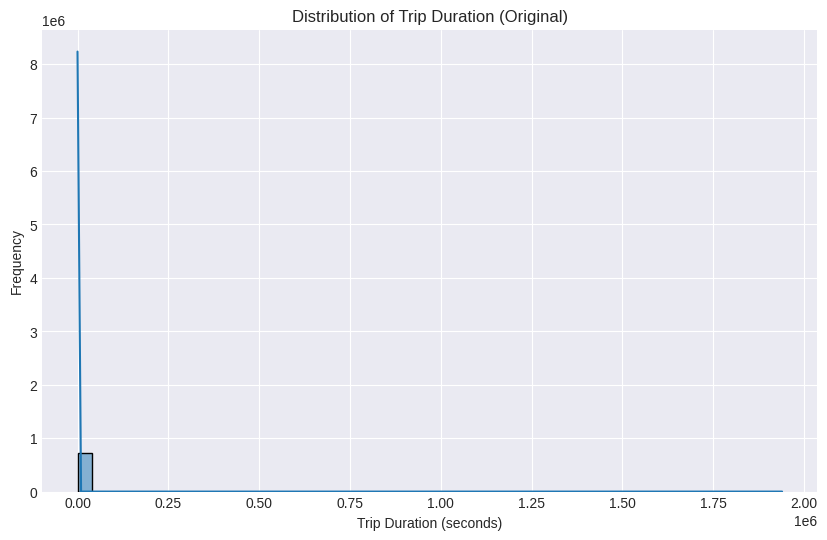

Original trip_duration min: 1
Original trip_duration max: 1939736
Original trip_duration 99th percentile: 3429.0


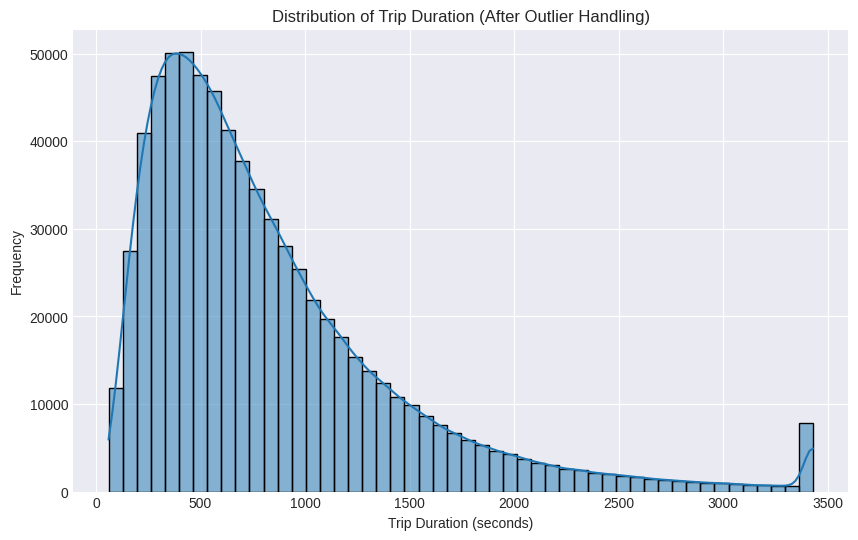

Cleaned trip_duration min: 60
Cleaned trip_duration max: 3429
Cleaned trip_duration mean: 838.3531282627015
Number of rows after cleaning: 725051


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of trip_duration before outlier handling
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration (Original)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

print(f"Original trip_duration min: {df['trip_duration'].min()}")
print(f"Original trip_duration max: {df['trip_duration'].max()}")
print(f"Original trip_duration 99th percentile: {df['trip_duration'].quantile(0.99)}")

# Cap trip_duration at the 99th percentile to handle extreme outliers
upper_bound = df['trip_duration'].quantile(0.99)
df['trip_duration_cleaned'] = df['trip_duration'].clip(upper=upper_bound)

# Remove trips with duration less than a reasonable minimum (e.g., 60 seconds)
df = df[df['trip_duration_cleaned'] >= 60]

# Visualize the distribution of trip_duration after outlier handling
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_duration_cleaned'], bins=50, kde=True)
plt.title('Distribution of Trip Duration (After Outlier Handling)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

print(f"Cleaned trip_duration min: {df['trip_duration_cleaned'].min()}")
print(f"Cleaned trip_duration max: {df['trip_duration_cleaned'].max()}")
print(f"Cleaned trip_duration mean: {df['trip_duration_cleaned'].mean()}")
print(f"Number of rows after cleaning: {len(df)}")

## Visualize Predictions

### Subtask:
Generate a scatter plot to visualize the actual trip durations versus the predicted trip durations from the model, including appropriate labels and a legend.


**Reasoning**:
To visualize the actual versus predicted trip durations, I will use `matplotlib.pyplot` to create a scatter plot, add a perfect prediction line, and include appropriate labels, a title, and a legend as instructed.



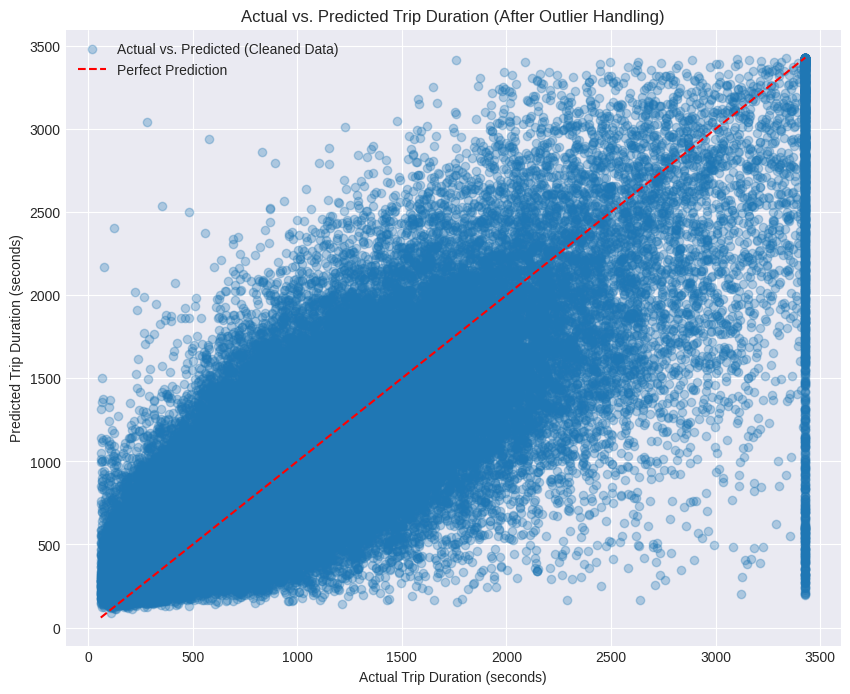

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create the scatter plot using the cleaned predictions
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_cleaned, alpha=0.3, label='Actual vs. Predicted (Cleaned Data)')

# Add a line representing perfect prediction
min_val = min(y_test.min(), y_pred_cleaned.min())
max_val = max(y_test.max(), y_pred_cleaned.max())

perfect_prediction_line = np.linspace(min_val, max_val, 100)
plt.plot(perfect_prediction_line, perfect_prediction_line, color='red', linestyle='--', label='Perfect Prediction')

# Label the axes and add a title
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.title('Actual vs. Predicted Trip Duration (After Outlier Handling)')

# Add a legend
plt.legend()

# Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the model's performance, including the calculated R-squared score, and discuss any insights gained from the predictions.


## Summary:

### Data Analysis Key Findings

* The nyc_taxi_trip_duration.csv dataset contains 729,322 entries and 11 columns, with no missing values.
* Initial inspection revealed extreme outliers in trip_duration (from 1 to over 1.9 million seconds).
* pickup_datetime and dropoff_datetime were successfully converted to datetime objects.
* Feature engineering included extracting time-based features (hour, day of week, month, year), calculating Haversine distance, and encoding store_and_fwd_flag.
* The data was split into training (approx. 80%) and testing (approx. 20%) sets.
* Initial RandomForestRegressor model performed poorly, with an R-squared score of -0.0188.
* Outliers in trip_duration were handled by capping at the 99th percentile (3429 seconds) and removing trips under 60 seconds, reducing the dataset to 725,051 rows.
* After retraining the RandomForestRegressor with cleaned data, the R-squared score significantly improved to 0.6732.
* The scatter plot for cleaned data shows a much stronger correlation between actual and predicted trip durations.

### Insights

* Handling outliers in the target variable was crucial and drastically improved the model's predictive power.
* The current R-squared score of 0.6732 is a good starting point but can be improved further.

### Potential future steps include:
* Hyperparameter Tuning: Optimizing model parameters using methods like GridSearchCV.
* Advanced Feature Engineering: Creating more sophisticated features, potentially using external data (weather, traffic) or geographical clustering.
* Exploring Other Models: Experimenting with Gradient Boosting algorithms (XGBoost, LightGBM, CatBoost).
* Target Variable Transformation: Considering a log transformation on trip_duration_cleaned if its distribution remains skewed.